In [ ]:
import boto3
import pandas as pd

# Create s3 client
s3 = boto3.client('s3', region_name = 'us-east-1')

dfs = []
bucket = "dsan6000-mm5514"

# Loop through s3 bucket, read parquet file as dataframe
for file in s3.list_objects_v2(Bucket=bucket, Prefix="wikipedia-hourly/")["Contents"]:
    key = file["Key"]
    df = pd.read_parquet(f"s3://{bucket}/{key}")
    dfs.append(df)

# Concat dataframes together
large_df = pd.concat(dfs, ignore_index=True)

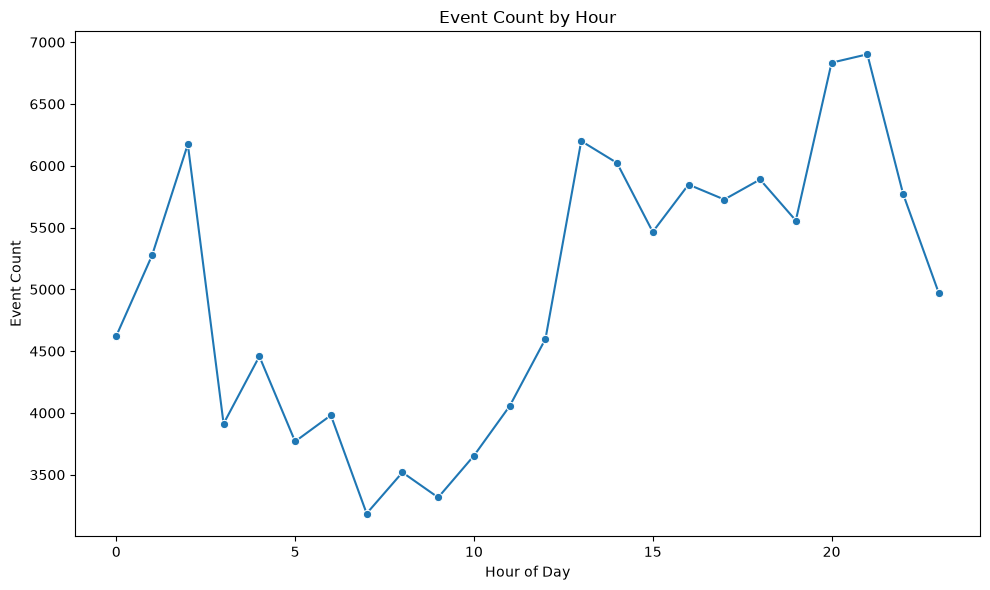

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create hourly counts
large_df['datetime'] = pd.to_datetime(large_df['datetime'])
hourly_counts = large_df['datetime'].dt.hour.value_counts().sort_index().rename_axis('hour').reset_index(name='count')

# Hourly Counts Line Graph
plt.figure(figsize=(10, 6))
sns.lineplot(data=hourly_counts, x='hour', y='count', marker='o')

# Labels and title
plt.title('Event Count by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Event Count')

# Save plots
plt.savefig('images/hourly-events.svg', format='svg')
plt.savefig('images/hourly-events.png', format='png')

# Display
plt.tight_layout()
plt.show()

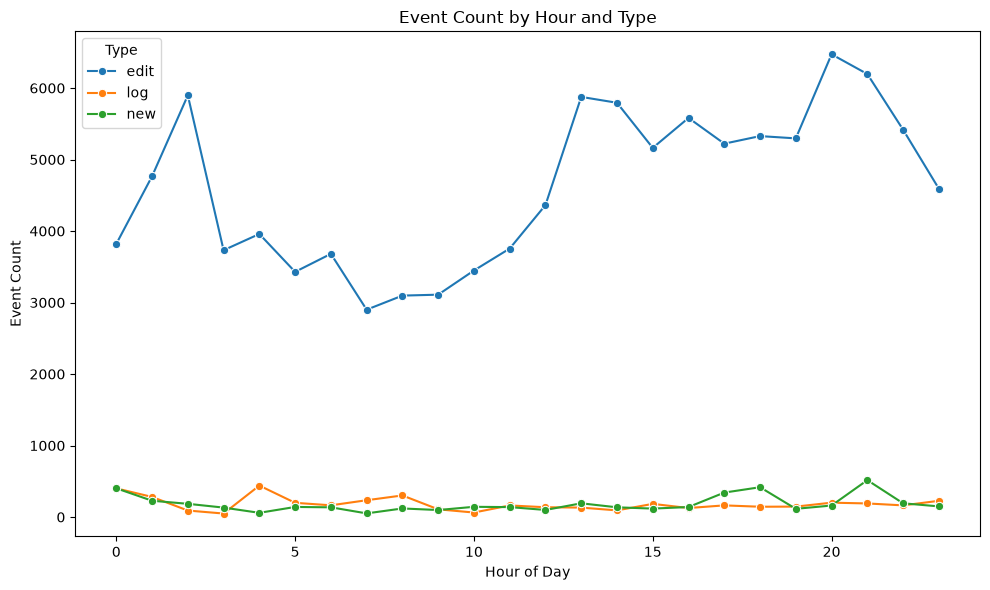

In [ ]:
# Create counts by hour and type
type_counts = (large_df.groupby([large_df['datetime'].dt.hour, 'type']).size().reset_index(name='count'))
type_counts.columns = ['hour', 'type', 'count']

# Hourly Event Counts Line Graph
plt.figure(figsize=(10, 6))
sns.lineplot(data=type_counts, x='hour', y='count', hue='type', marker='o')

# Labels and title
plt.title('Event Count by Hour and Type')
plt.xlabel('Hour of Day')
plt.ylabel('Event Count')
plt.legend(title='Type')

# Save off plots
plt.savefig('images/events-by-type.svg', format='svg')
plt.savefig('images/events-by-type.png', format='png')

# Display
plt.tight_layout()
plt.show()